  Customer ID  Gender  Age Married  Number of Dependents          City  \
0  0002-ORFBO  Female   37     Yes                     0  Frazier Park   
1  0003-MKNFE    Male   46      No                     0      Glendale   
2  0004-TLHLJ    Male   50      No                     0    Costa Mesa   
3  0011-IGKFF    Male   78     Yes                     0      Martinez   
4  0013-EXCHZ  Female   75     Yes                     0     Camarillo   

   Zip Code   Latitude   Longitude  Number of Referrals  ...   Payment Method  \
0     93225  34.827662 -118.999073                    2  ...      Credit Card   
1     91206  34.162515 -118.203869                    0  ...      Credit Card   
2     92627  33.645672 -117.922613                    0  ...  Bank Withdrawal   
3     94553  38.014457 -122.115432                    1  ...  Bank Withdrawal   
4     93010  34.227846 -119.079903                    3  ...      Credit Card   

  Monthly Charge Total Charges  Total Refunds Total Extra Data Charg

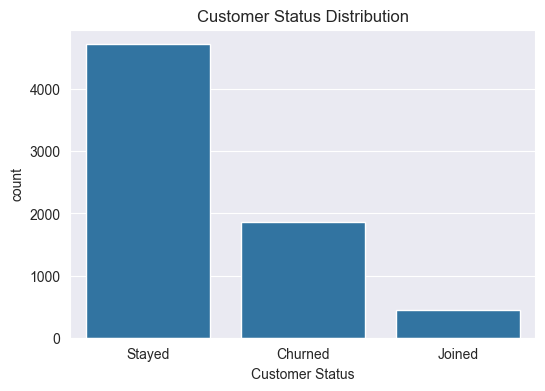

Accuracy: 0.8325053229240597

Classification Report:

              precision    recall  f1-score   support

           0       0.72      0.60      0.65       373
           1       0.72      0.61      0.66        97
           2       0.88      0.95      0.91       939

    accuracy                           0.83      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.82      0.83      0.83      1409



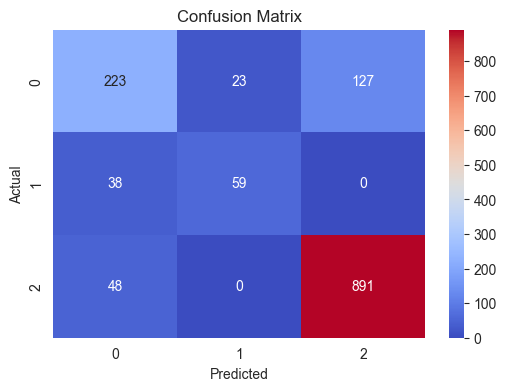

In [1]:
# ============================================
# 1. Import Libraries
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================
# 2. Load Excel Dataset
# ============================================

dataset = pd.read_excel(r"C:\Users\atapa\Downloads\Telecom Customer Churn Analysis.xlsx")

print(dataset.head())

# ============================================
# 3. Basic Data Exploration
# ============================================

print(dataset.info())
print(dataset.describe())
print(dataset.isnull().sum())

# ============================================
# 4. Churn Distribution
# ============================================

plt.figure(figsize=(6,4))
sns.countplot(x='Customer Status', data=dataset)
plt.title("Customer Status Distribution")
plt.show()

# ============================================
# 5. Data Cleaning
# ============================================

dataset.drop([
    'Customer ID',
    'Latitude',
    'Longitude',
    'Zip Code',
    'Churn Category',
    'Churn Reason'
], axis=1, inplace=True)

# ============================================
# 6. Encode Categorical Columns
# ============================================

labelencoder = LabelEncoder()

for col in dataset.select_dtypes(include='object').columns:
    dataset[col] = labelencoder.fit_transform(dataset[col])

# ============================================
# 7. Feature Selection
# ============================================

X = dataset.drop("Customer Status", axis=1)
y = dataset["Customer Status"]

# ============================================
# 8. Train Test Split
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ============================================
# 9. Feature Scaling
# ============================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================
# 10. Train Model
# ============================================

model = RandomForestClassifier(n_estimators=200, random_state=42)

model.fit(X_train, y_train)

# ============================================
# 11. Prediction
# ============================================

y_pred = model.predict(X_test)

# ============================================
# 12. Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================
# 13. Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()